# Module 04: Seaborn for Machine Learning
## Notebook 04: Multi-Plot Grids and Complete EDA Workflow

Before building a machine learning model, a data scientist must conduct an end-to-end Exploratory Data Analysis (EDA) to understand feature distributions, class balance, outliers, and inter-feature interactions. In this notebook, we explore `PairGrid`, `pairplot`, and implement a modular, automated EDA diagnostic pipeline.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Generate pairwise multi-feature grids using `sns.pairplot()`.
2. Customize upper, lower, and diagonal subplots with `sns.PairGrid()`.
3. Construct arbitrary small-multiple grids using `sns.FacetGrid()`.
4. Implement a systematic 5-step EDA workflow for machine learning datasets.
5. **Advanced:** Build a reusable, automated EDA diagnostic reporting pipeline with statistical skewness screening and faceted summaries.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

rng = np.random.default_rng(42)
sns.set_theme(style="ticks")
print("Seaborn loaded!")

Seaborn loaded!


### 1. The Classic Pair Plot: `sns.pairplot()`

`sns.pairplot()` creates an $N \times N$ matrix of plots:
- **Diagonal:** Univariate distributions (KDE or histogram) of each feature.
- **Off-Diagonal:** Bivariate scatterplots of every feature against every other feature.
- Mapped with `hue='Target'`, it immediately reveals which feature combinations linearly separate classes!

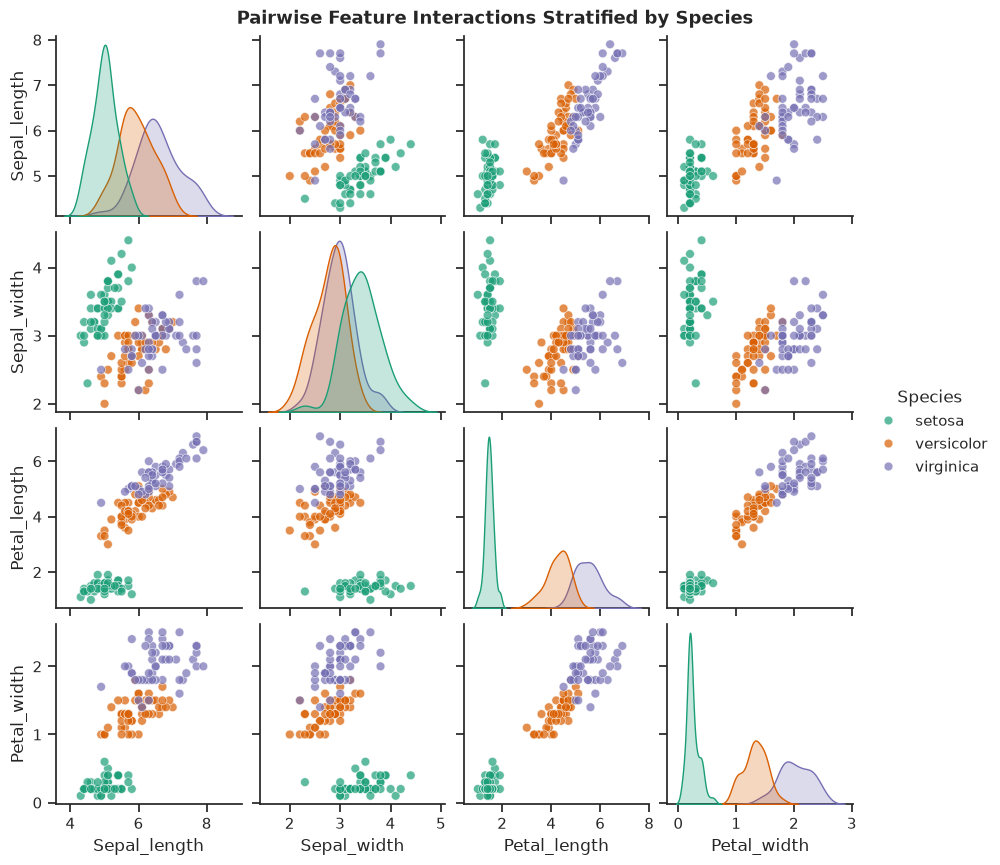

In [2]:
# Load the Iris dataset
df_iris = sns.load_dataset('iris')
df_iris.columns = [c.capitalize() for c in df_iris.columns]

# Create pairplot with KDE diagonals
g = sns.pairplot(
    df_iris,
    hue='Species',
    diag_kind='kde',
    palette='Dark2',
    plot_kws={'alpha': 0.7, 's': 40},
    height=2.2
)
g.fig.subplots_adjust(top=0.95)
g.fig.suptitle("Pairwise Feature Interactions Stratified by Species", fontsize=13, fontweight='bold')
plt.show()

---
### 2. Granular Customization with `sns.PairGrid`

While `pairplot` is an automated high-level wrapper, `PairGrid` allows you to assign **completely different plot types** to the upper triangle, lower triangle, and diagonal:
- `g.map_diag()`: Histograms or KDEs on the diagonal.
- `g.map_upper()`: Scatter plots with regression lines.
- `g.map_lower()`: 2D KDE contour density plots.

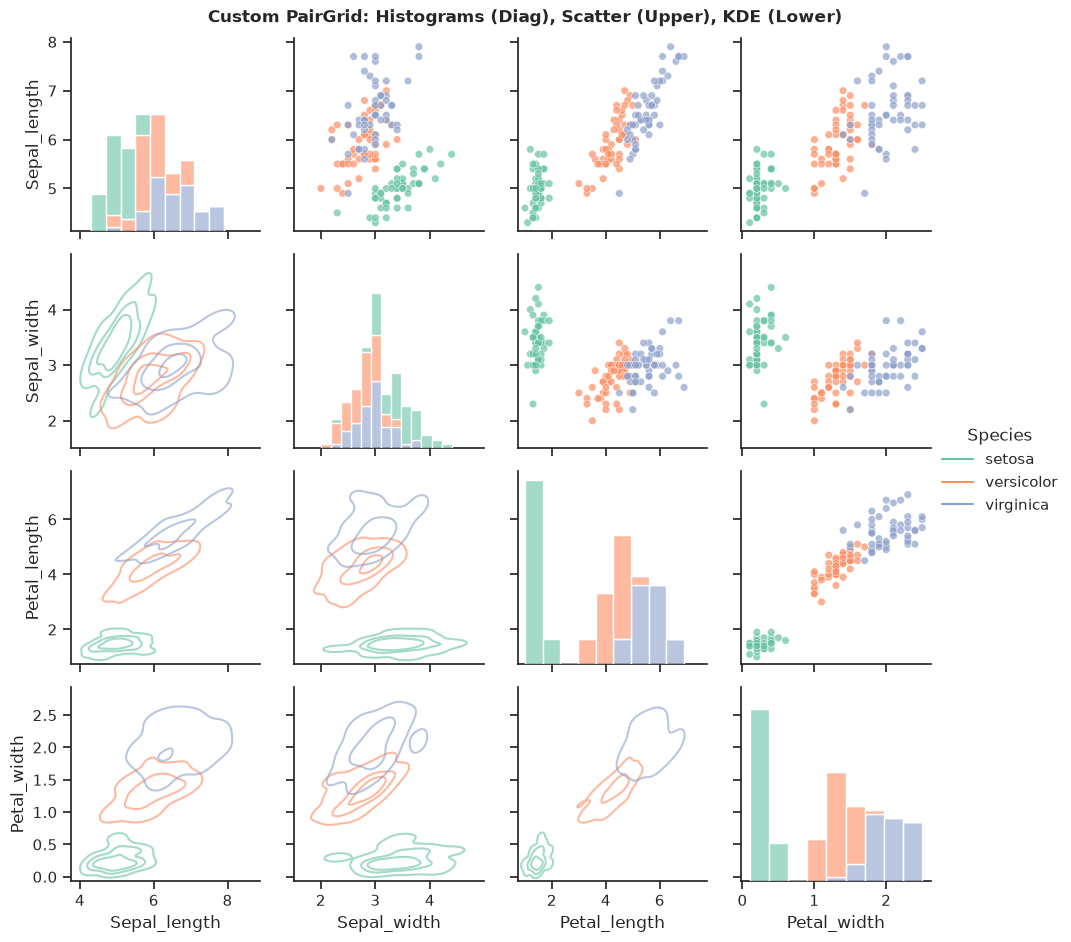

In [3]:
g_custom = sns.PairGrid(df_iris, hue='Species', palette='Set2', height=2.4)

# Map specific visualizations to distinct matrix regions
g_custom.map_diag(sns.histplot, multiple="stack", alpha=0.6)
g_custom.map_upper(sns.scatterplot, alpha=0.7, s=30)
g_custom.map_lower(sns.kdeplot, levels=4, alpha=0.6)

g_custom.add_legend()
g_custom.fig.subplots_adjust(top=0.95)
g_custom.fig.suptitle("Custom PairGrid: Histograms (Diag), Scatter (Upper), KDE (Lower)", fontsize=12, fontweight='bold')
plt.show()

---
### 3. The 5-Step Systematic EDA Framework

A professional EDA report follows 5 systematic steps:
1. **Dimension & Data Audit**: Dimensions, missingness, datatypes.
2. **Target Distribution Audit**: Class balance (evaluating whether accuracy is an appropriate metric).
3. **Univariate Feature Analysis**: Detecting feature skewness and heavy tails.
4. **Bivariate Target Separation**: Which individual features clearly separate classes?
5. **Multivariate Interactions**: High correlation and non-linear boundaries.

=== Step 1: Shape & Missingness ===
Dataset Shape: (150, 5)
Missing Values: 0

=== Step 2: Target Balance ===
Species
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64


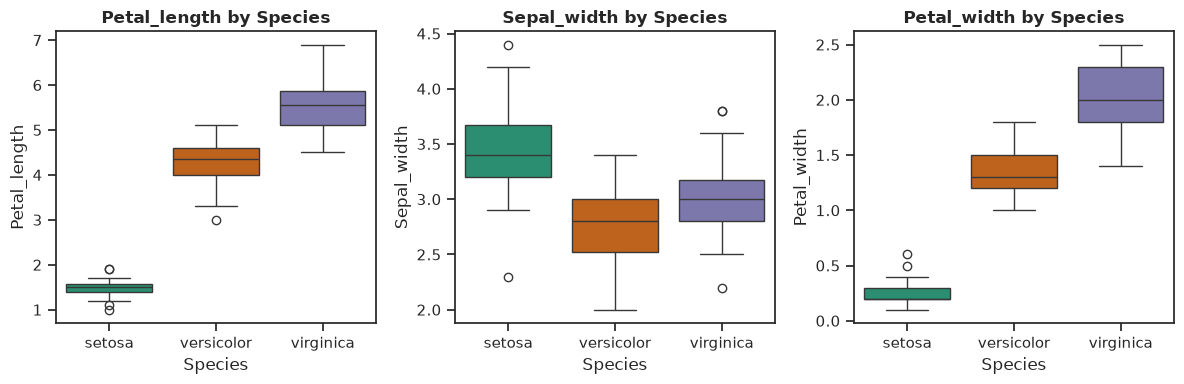

In [4]:
# Step 1: Data Audit
print("=== Step 1: Shape & Missingness ===")
print(f"Dataset Shape: {df_iris.shape}")
print(f"Missing Values: {df_iris.isna().sum().sum()}")

# Step 2: Target Balance
print("\n=== Step 2: Target Balance ===")
print(df_iris['Species'].value_counts(normalize=True))

# Step 4: Individual Feature Separation Boxplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
features = ['Petal_length', 'Sepal_width', 'Petal_width']

for i, feat in enumerate(features):
    sns.boxplot(data=df_iris, x='Species', y=feat, hue='Species', palette='Dark2', legend=False, ax=axes[i])
    axes[i].set_title(f"{feat} by Species", fontweight='bold')

plt.tight_layout()
plt.show()

---
### 4. Advanced Complex Usage: Automated EDA Diagnostic Pipeline

In production ML environments, data scientists construct automated diagnostic pipelines that consume any arbitrary tabular dataset and report:
1. Distribution skewness flags ($|\text{skew}| > 1.0$) indicating candidate features for log-transformations.
2. Target separation ranking via ANOVA F-statistic or correlation.
3. Multi-faceted automated violin plots comparing top predictors.

=== Automated EDA Diagnostic Audit ===
Total Observations: 150
Features Analyzed:  ['Sepal_length', 'Sepal_width', 'Petal_length', 'Petal_width']
Skewed Features Requiring Normalization:
Series([], dtype: float64)



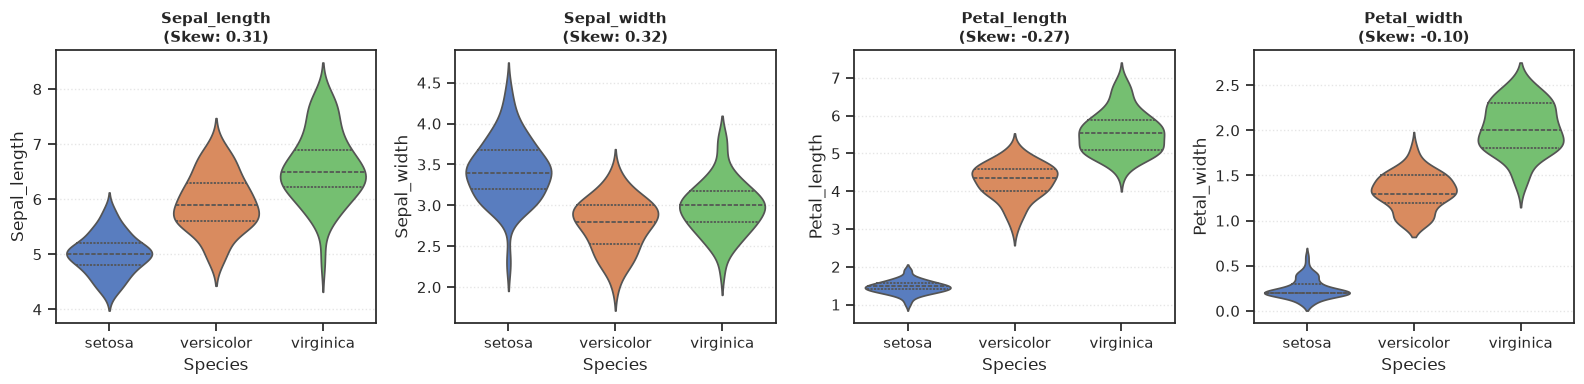

In [5]:
def automated_eda_audit(df: pd.DataFrame, num_features: list, target_col: str):
    # Compute statistical skewness
    skew_scores = df[num_features].skew()
    skewed_flags = skew_scores[abs(skew_scores) > 0.5]
    
    print("=== Automated EDA Diagnostic Audit ===")
    print(f"Total Observations: {len(df)}")
    print(f"Features Analyzed:  {num_features}")
    print(f"Skewed Features Requiring Normalization:\n{skewed_flags}\n")
    
    # Generate Faceted Diagnostic Plots
    fig, axes = plt.subplots(1, len(num_features), figsize=(4 * len(num_features), 4))
    if len(num_features) == 1:
        axes = [axes]
        
    for ax, feat in zip(axes, num_features):
        sns.violinplot(data=df, x=target_col, y=feat, hue=target_col, palette='muted', legend=False, inner='quartile', ax=ax)
        ax.set_title(f"{feat}\n(Skew: {skew_scores[feat]:.2f})", fontsize=11, fontweight='bold')
        ax.grid(axis='y', linestyle=':', alpha=0.5)
        
    plt.tight_layout()
    plt.show()

# Run the automated audit on iris dataset
iris_nums = ['Sepal_length', 'Sepal_width', 'Petal_length', 'Petal_width']
automated_eda_audit(df_iris, iris_nums, target_col='Species')

### Module 04 Conclusion & Congratulations!
You have successfully completed **Module 04: Seaborn for Machine Learning**!

Throughout these 4 notebooks, you mastered:
1. Figure-level vs Axes-level architecture and continuous density estimation (`01_architecture_and_distribution_plots.ipynb`).
2. Multi-attribute relational plots, bootstrap confidence intervals, and categorical distributions (`02_relational_and_categorical_plots.ipynb`).
3. Masked correlation heatmaps, multicollinearity auditing, and hierarchical clustermaps (`03_matrix_plots_and_correlation_heatmaps.ipynb`).
4. Pair plots, Facet grids, and automated EDA diagnostic reporting (`04_multi_plot_grids_and_eda_workflow.ipynb`).

**Up Next:** Proceed to **Module 05: Scikit-Learn** to build end-to-end supervised and unsupervised machine learning pipelines!